<a href="https://colab.research.google.com/github/adhiss387-code/02_fraud_detection_pipeline/blob/main/cash_flow_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 1. Install required packages
!pip install prophet openpyxl plotly -q

# 2. Import Python modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from prophet import Prophet
import warnings
import logging

# Suppress unnecessary warnings and verbose logs
warnings.filterwarnings('ignore')
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Set random seed for consistent results
np.random.seed(42)

# Generate 36 Months of Historical Financial Data (2023 - 2025)
dates = pd.date_range(start="2023-01-01", periods=36, freq="MS")

# Base trend + seasonality + random noise
trend = np.linspace(500000, 1200000, 36)
seasonality = 150000 * np.sin(np.linspace(0, 6 * np.pi, 36))
noise = np.random.normal(0, 30000, 36)
revenue = trend + seasonality + noise
opex = revenue * np.random.uniform(0.60, 0.70, 36)
net_cash_flow = revenue - opex

# Build DataFrame
df = pd.DataFrame({
    'Date': dates,
    'Revenue': np.round(revenue, 2),
    'OpEx': np.round(opex, 2),
    'NetCashFlow': np.round(net_cash_flow, 2)
})

# Display first 5 rows
df.head()

,Date,Revenue,OpEx,NetCashFlow
0,2023-01-01,514901.42,324990.90,189910.52
1,2023-02-01,592786.96,386501.13,206285.83
2,2023-03-01,691519.99,452718.10,238801.89
3,2023-04-01,755539.86,467290.40,288249.45
4,2023-05-01,698161.39,486589.49,211571.90


In [4]:
# Create interactive Plotly figure
fig = go.Figure()
fig.add_trace(go.Scatter(x=df['Date'], y=df['Revenue'], mode='lines+markers', name='Revenue (₹)'))
fig.add_trace(go.Scatter(x=df['Date'], y=df['OpEx'], mode='lines+markers', name='Operating Expenses (₹)'))
fig.add_trace(go.Scatter(x=df['Date'], y=df['NetCashFlow'], mode='lines+markers', name='Net Cash Flow (₹)'))

fig.update_layout(
    title='36-Month Financial Trend (2023 - 2025)',
    xaxis_title='Date',
    yaxis_title='Amount (₹)',
    hovermode='x unified'
)
fig.show()

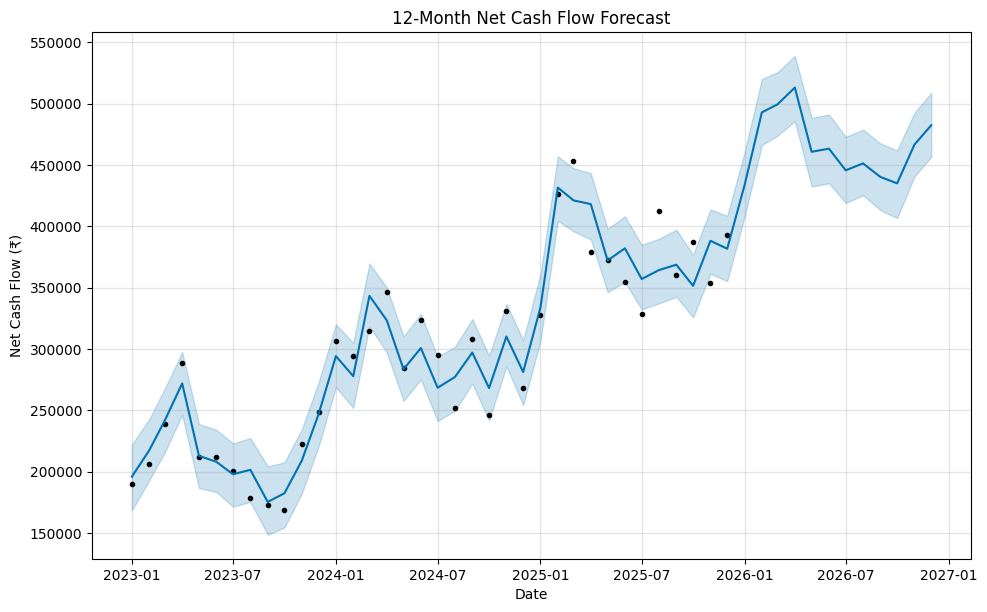

In [5]:
# Prepare data for Prophet (requires 'ds' and 'y' columns)
df_prophet = df[['Date', 'NetCashFlow']].rename(columns={'Date': 'ds', 'NetCashFlow': 'y'})

# Fit model
model = Prophet(yearly_seasonality=True)
model.fit(df_prophet)

# Create future dataframe for next 12 months
future = model.make_future_dataframe(periods=12, freq='MS')
forecast = model.predict(future)

# Plot forecast graph
fig_forecast = model.plot(forecast)
plt.title("12-Month Net Cash Flow Forecast")
plt.xlabel("Date")
plt.ylabel("Net Cash Flow (₹)")
plt.show()